In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.utils import add_self_loops
from torch_geometric.nn import MessagePassing
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random
import os
import numpy as np

In [21]:


# def seed_everything(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)

#     os.environ["PYTHONHASHSEED"] = str(seed)

# seed_everything(42)

In [22]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

In [23]:
print('Total number of training nodes before split: ',data.train_mask.sum().item())
print('Total number of test nodes before split: ',data.test_mask.sum())
print('Total number of val nodes before split: ',data.val_mask.sum())


Total number of training nodes before split:  140
Total number of test nodes before split:  tensor(1000)
Total number of val nodes before split:  tensor(500)


In [24]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [25]:
num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)
train_size = int(0.7 * num_nodes)
val_size = int(0.15 * num_nodes)
test_size = num_nodes - train_size - val_size
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[indices[:train_size]] = True
val_mask[indices[train_size:train_size+val_size]] = True
test_mask[indices[train_size+val_size:]] = True
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print("Train nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

Train nodes: 1895
Validation nodes: 406
Test nodes: 407


In [26]:
class NeutrosophicFuzzification(nn.Module):
    def __init__(self, alpha=0.5, beta=2.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta

    def forward(self, x):
        mean = x.mean(dim=0, keepdim=True)
        std = x.std(dim=0, keepdim=True) + 1e-6

        T = torch.exp(-((x - mean)**2) / (2 * std**2))
        F_ns = 1 - torch.exp(-((x - mean)**2) / (2 * (self.alpha * std)**2))
        I = 1 - torch.exp(-((x - mean)**2) / (2 * (self.beta * std)**2))

        combined = torch.stack([T, I, F_ns], dim=2)
        return combined

In [27]:
fuzzifier = NeutrosophicFuzzification(alpha=0.5, beta=2.0)
fuzzifier = NeutrosophicFuzzification(alpha=0.5, beta=2.0)
x_ns = fuzzifier(data.x)
print('The shape of the fuzzified input is:', x_ns.shape)
print('The 1 fuzzified input is:', x_ns[:1])

The shape of the fuzzified input is: torch.Size([2708, 1433, 3])
The 1 fuzzified input is: tensor([[[9.9703e-01, 7.4238e-04, 1.1812e-02],
         [9.9385e-01, 1.5402e-03, 2.4362e-02],
         [9.8682e-01, 3.3101e-03, 5.1668e-02],
         ...,
         [9.9889e-01, 2.7740e-04, 4.4295e-03],
         [9.8778e-01, 3.0683e-03, 4.7979e-02],
         [9.9778e-01, 5.5599e-04, 8.8590e-03]]])


In [28]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv
from torch_geometric.utils import add_self_loops, degree

class NGNNLayer(nn.Module):
    """
    Neutrosophic GNN layer that applies a GCNConv to each of the three
    neutrosophic channels (T, I, F) separately.
    
    Input:  [N, in_channels, 3]
    Output: [N, out_channels, 3]
    """
    def __init__(self, in_channels, out_channels, bias=True, share_weights=True):
        super().__init__()
        
        self.share_weights = share_weights
        
        if share_weights:
            # Single GCNConv reused for all three channels (same weights)
            self.conv = GCNConv(in_channels, out_channels, bias=bias)
            self.conv_T = self.conv
            self.conv_I = self.conv
            self.conv_F = self.conv
        else:
            # Separate GCNConv for each channel
            self.conv_T = GCNConv(in_channels, out_channels, bias=bias)
            self.conv_I = GCNConv(in_channels, out_channels, bias=bias)
            self.conv_F = GCNConv(in_channels, out_channels, bias=bias)
    
    def forward(self, x, edge_index):
        # x: [N, C_in, 3]
        
        # Extract each channel as a 2D tensor [N, C_in]
        T = x[:, :, 0]
        I = x[:, :, 1]
        F = x[:, :, 2]
        
        # Apply GCNConv to each channel independently
        T_out = self.conv_T(T, edge_index)
        I_out = self.conv_I(I, edge_index)
        F_out = self.conv_F(F, edge_index)
        
        # Stack back to [N, C_out, 3]
        out = torch.stack([T_out, I_out, F_out], dim=2)
        return out

In [29]:
ngnn = NGNNLayer(in_channels=1433, out_channels=64)
out = ngnn(x_ns, data.edge_index)
print(out)


tensor([[[-1.7107e-01, -2.8034e-02,  4.9465e-02],
         [-1.3374e+00, -8.0010e-02, -1.1504e-01],
         [ 1.4501e+00, -1.1774e-01, -8.1069e-02],
         ...,
         [-6.4145e-01,  3.6074e-02,  1.1193e-01],
         [-4.7236e-01, -1.7409e-01, -2.4357e-01],
         [ 1.9333e+00,  7.2362e-02,  2.3362e-01]],

        [[-1.9955e-01, -1.4040e-02,  6.6601e-02],
         [-1.6542e+00,  4.2276e-02,  9.2811e-03],
         [ 1.5426e+00, -5.0608e-02, -5.5839e-03],
         ...,
         [-5.9340e-01, -7.2970e-02,  1.2042e-02],
         [-8.7512e-01,  9.9223e-02,  3.8505e-02],
         [ 2.1949e+00,  9.5240e-02,  2.5928e-01]],

        [[-2.8175e-01,  6.4057e-02,  1.4768e-01],
         [-1.6182e+00,  1.1074e-01,  7.2347e-02],
         [ 1.4033e+00, -1.5658e-03,  3.9003e-02],
         ...,
         [-7.2193e-01,  8.9096e-02,  1.6481e-01],
         [-7.1713e-01, -2.0146e-03, -6.3751e-02],
         [ 2.0243e+00,  1.3091e-01,  2.8182e-01]],

        ...,

        [[-2.1879e-01, -5.2100e-03,  8

In [30]:
class NGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.fuzz = NeutrosophicFuzzification()
        self.dropout = dropout
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels

        # New NGNNLayer using GCNConv (three separate convolutions)
        self.layer1 = NGNNLayer(in_channels, hidden_channels)
        self.layer2 = NGNNLayer(hidden_channels, out_channels)

        # LayerNorm after flattening the three channels
        self.norm1 = nn.LayerNorm(hidden_channels * 3)
        self.norm2 = nn.LayerNorm(out_channels * 3)

        # Learnable weights for defuzzification (weighted sum of T, I, F)
        self.rule_weights = nn.Parameter(torch.tensor([1.0, 0.5, 0.5]))

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        num_nodes = x.size(0)

        # Fuzzification: [num_nodes, in_channels] -> [num_nodes, in_channels, 3]
        combined = self.fuzz(x)

        # Layer 1
        combined = self.layer1(combined, edge_index)  # [num_nodes, hidden, 3]

        # Flatten -> Norm -> ReLU -> Dropout -> Reshape
        combined = combined.view(num_nodes, -1)  # [num_nodes, hidden * 3]
        combined = self.norm1(combined)
        combined = torch.nn.functional.relu(combined)
        combined = torch.nn.functional.dropout(combined, p=self.dropout, training=self.training)
        combined = combined.view(num_nodes, self.hidden_channels, 3)  # [num_nodes, hidden, 3]

        # Layer 2
        combined = self.layer2(combined, edge_index)  # [num_nodes, out, 3]

        # Flatten -> Norm -> Reshape
        combined = combined.view(num_nodes, -1)  # [num_nodes, out * 3]
        combined = self.norm2(combined)
        combined = combined.view(num_nodes, self.out_channels, 3)  # [num_nodes, out, 3]

        # Defuzzification: weighted sum over the three channels
        weights = torch.softmax(self.rule_weights, dim=0)  # [3]
        H = (combined * weights).sum(dim=2)  # [num_nodes, out]

        return H, torch.nn.functional.log_softmax(H, dim=1)

In [31]:
model = NGNN(
    in_channels=dataset.num_node_features,  # 1433 for Cora
    hidden_channels=64,
    out_channels=dataset.num_classes        # 7 for Cora
)

In [32]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
H, log_probs = model(data)

print("H shape:", H.shape)
print("Log probs shape:", log_probs.shape)
print("Pred sample:", log_probs.argmax(dim=1)[:10])

H shape: torch.Size([2708, 7])
Log probs shape: torch.Size([2708, 7])
Pred sample: tensor([3, 1, 5, 3, 5, 3, 3, 5, 3, 5])


In [33]:
# device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
# model = NGNN(
#     in_channels=dataset.num_node_features,
#     hidden_channels=128,  # Increased from 64
#     out_channels=dataset.num_classes,
#     dropout=0.3  # Reduced from 0.5
# ).to(device)

# data = data.to(device)

# optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=500, eta_min=1e-5)

best_val_acc = 0
best_model_state = None

train_losses, val_accs, test_accs = [], [], []

for epoch in range(1, 501):
    model.train()
    optimizer.zero_grad()
    _, out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()   # <-- CosineAnnealingLR updates per epoch

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        _, out = model(data)
        pred = out.argmax(dim=1)
        val_acc = (pred[data.val_mask] == data.y[data.val_mask]).float().mean().item()
        test_acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item()

    val_accs.append(val_acc)
    test_accs.append(test_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 20 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f} | LR: {current_lr:.2e}")

Epoch  20 | Loss: 1.8950 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 1.00e-04
Epoch  40 | Loss: 1.8676 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 5.00e-05
Epoch  60 | Loss: 1.8473 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 2.50e-05
Epoch  80 | Loss: 1.8520 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 1.25e-05
Epoch 100 | Loss: 1.8543 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 6.25e-06
Epoch 120 | Loss: 1.8614 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 3.13e-06
Epoch 140 | Loss: 1.8392 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 1.56e-06
Epoch 160 | Loss: 1.8448 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 7.81e-07
Epoch 180 | Loss: 1.8536 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 3.91e-07
Epoch 200 | Loss: 1.8370 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 1.95e-07
Epoch 220 | Loss: 1.8678 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 9.77e-08
Epoch 240 | Loss: 1.8497 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 4.88e-08
Epoch 260 | Loss: 1.8547 | Val Acc: 0.3005 | Test Acc: 0.3292 | LR: 2.44e-08

In [35]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def evaluate_metrics():
    model.eval()
    with torch.no_grad():
        H, out = model(data)
        pred = out.argmax(dim=1).cpu()
        true = data.y.cpu()

        test_idx = data.test_mask.cpu()
        y_true = true[test_idx]
        y_pred = pred[test_idx]

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)

    return acc, precision, recall, f1, cm

acc, precision, recall, f1, cm = evaluate_metrics()

print(f"Test Accuracy  : {acc:.4f}")
print(f"Test Precision : {precision:.4f}")
print(f"Test Recall    : {recall:.4f}")
print(f"Test F1 Score  : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

Test Accuracy  : 0.3292
Test Precision : 0.0470
Test Recall    : 0.1429
Test F1 Score  : 0.0708

Confusion Matrix:
[[  0   0   0  50   0   0   0]
 [  0   0   0  32   0   0   0]
 [  0   0   0  54   0   0   0]
 [  0   0   0 134   0   0   0]
 [  0   0   0  63   0   0   0]
 [  0   0   0  45   0   0   0]
 [  0   0   0  29   0   0   0]]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [36]:
model.eval()
with torch.no_grad():
    out = model(data)
    pred = out[0].argmax(dim=1)  # <-- index into tuple

test_correct = pred[data.test_mask] == data.y[data.test_mask]
wrong_mask = ~test_correct

total_wrong = wrong_mask.sum().item()
total_test = data.test_mask.sum().item()

print(f"Wrong predictions : {total_wrong}")
print(f"Total test nodes  : {total_test}")
print(f"Accuracy          : {(total_test - total_wrong) / total_test:.4f}")


Wrong predictions : 273
Total test nodes  : 407
Accuracy          : 0.3292


In [37]:
# Make predictions
model.eval()
with torch.no_grad():
    H, out = model(data)
    pred = out.argmax(dim=1)

# Only consider test nodes
test_idx = data.test_mask.nonzero(as_tuple=True)[0]
y_true = data.y[test_idx]
y_pred = pred[test_idx]

# Find misclassified nodes
wrong_idx = test_idx[y_true != y_pred]

print(f"Total wrong predictions in test set: {len(wrong_idx)}\n")
print("List of misclassified nodes (Node ID : Predicted -> Actual):")
for node in wrong_idx:
    print(f"Node {node.item()}: Pred = {y_pred[node == test_idx].item()}, Actual = {y_true[node == test_idx].item()}")

Total wrong predictions in test set: 273

List of misclassified nodes (Node ID : Predicted -> Actual):
Node 12: Pred = 3, Actual = 4
Node 22: Pred = 3, Actual = 4
Node 26: Pred = 3, Actual = 6
Node 33: Pred = 3, Actual = 4
Node 34: Pred = 3, Actual = 2
Node 38: Pred = 3, Actual = 4
Node 50: Pred = 3, Actual = 5
Node 55: Pred = 3, Actual = 4
Node 56: Pred = 3, Actual = 6
Node 64: Pred = 3, Actual = 2
Node 83: Pred = 3, Actual = 2
Node 98: Pred = 3, Actual = 0
Node 106: Pred = 3, Actual = 6
Node 109: Pred = 3, Actual = 1
Node 114: Pred = 3, Actual = 5
Node 116: Pred = 3, Actual = 6
Node 135: Pred = 3, Actual = 1
Node 139: Pred = 3, Actual = 1
Node 144: Pred = 3, Actual = 6
Node 145: Pred = 3, Actual = 6
Node 155: Pred = 3, Actual = 2
Node 166: Pred = 3, Actual = 4
Node 181: Pred = 3, Actual = 6
Node 186: Pred = 3, Actual = 0
Node 191: Pred = 3, Actual = 5
Node 196: Pred = 3, Actual = 4
Node 203: Pred = 3, Actual = 4
Node 211: Pred = 3, Actual = 0
Node 220: Pred = 3, Actual = 5
Node 224: 

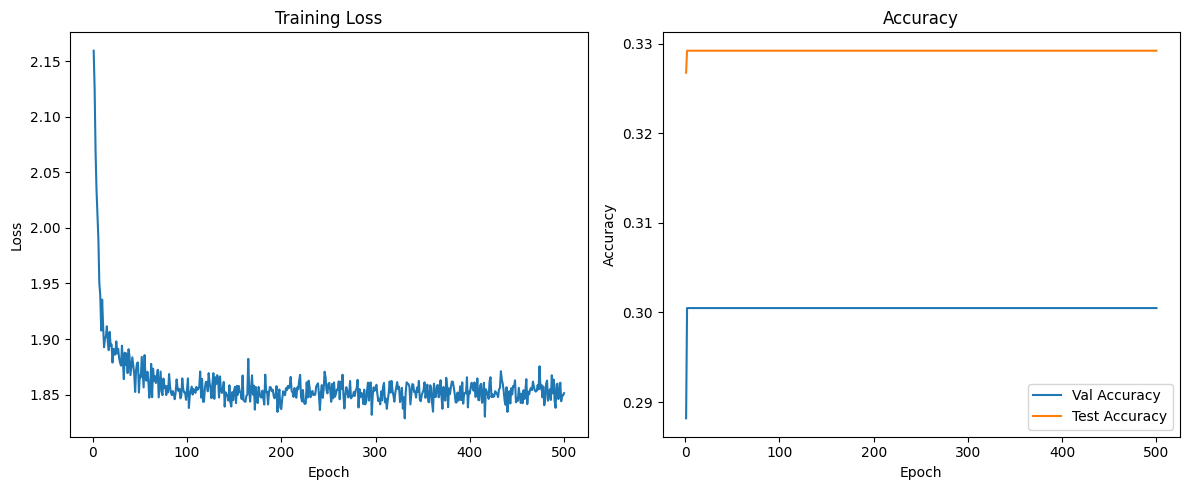

In [38]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.plot(epochs, test_accs, label="Test Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()